# Analysis of American Parlimentary Debate Association Rounds Fall 2019 - Spring 2026

## Exploratory Data Analysis -- General Information

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from scipy import stats
from matplotlib.ticker import MaxNLocator

In [2]:
df_rounds = pd.read_csv("Rounds.csv")
df_rounds_with_judge_id = pd.read_csv("Rounds_With_Identified_Judges.csv")
debate_roster = pd.read_csv("All_Debaters.csv")

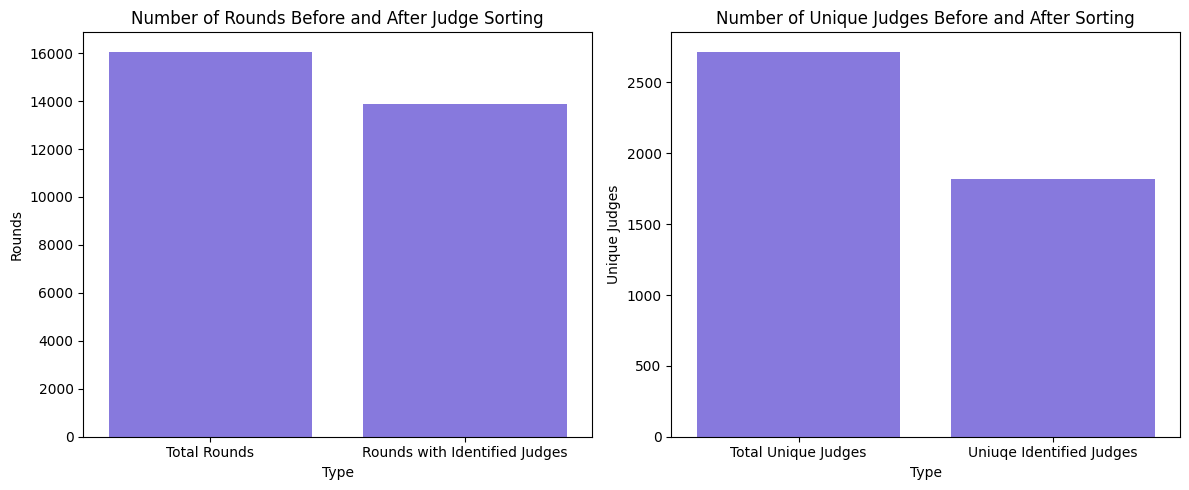

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_rounds_data = pd.DataFrame([[df_rounds.shape[0], "Total Rounds"], [df_rounds_with_judge_id.shape[0], "Rounds with Identified Judges"]], columns=["Rounds","Type"])
sns.barplot(df_rounds_data, x="Type", y="Rounds", orient='v', color="mediumslateblue", ax=axes[0])
axes[0].set_title("Number of Rounds Before and After Judge Sorting")

df_debaters_data = pd.DataFrame([[len(df_rounds["Judge"].unique()), "Total Unique Judges"], [len(df_rounds_with_judge_id["Judge"].unique()), "Uniuqe Identified Judges"]], columns=["Unique Judges", "Type"])
sns.barplot(df_debaters_data, x="Type", y="Unique Judges", orient='v', color="mediumslateblue", ax=axes[1])
axes[1].set_title("Number of Unique Judges Before and After Sorting")

plt.tight_layout()
plt.show()

In [4]:
print("Number of rounds before sorting: ", df_rounds.shape[0])
print("Number of rounds after sorting: ", df_rounds_with_judge_id.shape[0])
print("Number of unique judges: ", len(df_rounds["Judge"].unique()))
print("Number of unique identified judges: ", len(df_rounds_with_judge_id["Judge"].unique()))

Number of rounds before sorting:  16064
Number of rounds after sorting:  13897
Number of unique judges:  2718
Number of unique identified judges:  1822


From this, we can see that the data spans 16,064 rounds. Finally, the rounds with identified judges are only 13,897. This means that there were 2,167 rounds that were dropped when the dataset of rounds and the valid, registered judges were merged. In these rounds, there were 896 unique judges. It can be assumed that the majority of these judges are individuals who have judged but have never competed in an APDA round themselves nor did they go on to compete. This is an important observation since 13.5% of all rounds fall into this group. This also means 32.7% of all unique judges appearing in APDA rounds are never registered with a school.

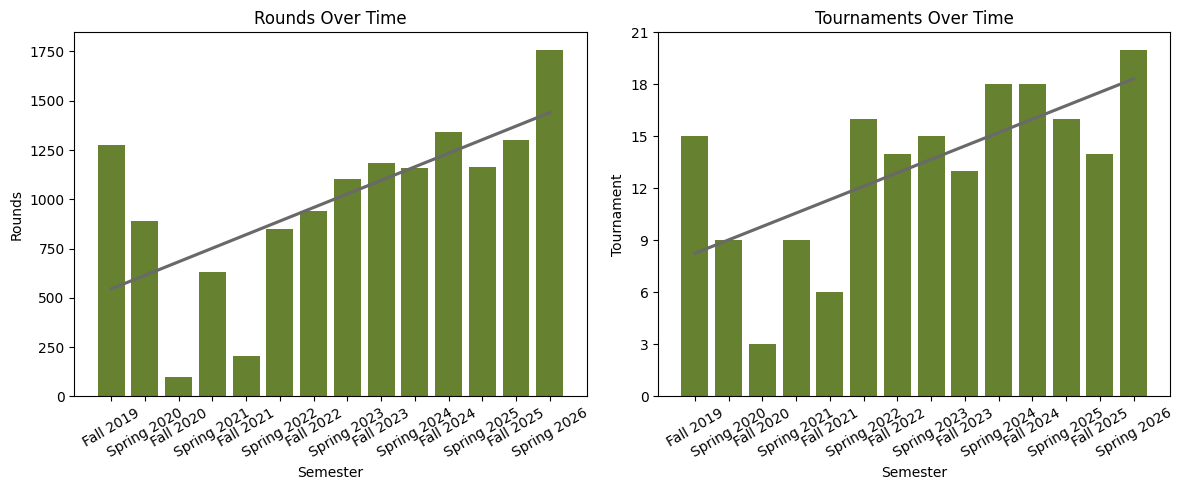

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_rounds_per_year = df_rounds_with_judge_id.groupby(['Year', 'Season'], as_index=False)["Speaker One Name"].count()
df_rounds_per_year = df_rounds_per_year.rename(columns={"Speaker One Name": "Rounds"})
df_rounds_per_year["Semester"] = df_rounds_per_year["Season"] + " " + df_rounds_per_year["Year"].astype(str)
df_rounds_per_year = df_rounds_per_year.sort_values(by="Season", ascending=False)
df_rounds_per_year = df_rounds_per_year.sort_values(by="Year", ascending=True)
sns.barplot(data=df_rounds_per_year, x="Semester", y="Rounds", color="olivedrab", ax=axes[0])
axes[0].set_title("Rounds Over Time")
axes[0].tick_params(axis='x', rotation=30)

df_tournaments_per_year = df_rounds_with_judge_id.drop_duplicates(subset=['Year', 'Season', 'Tournament'], keep='first')
df_tournaments_per_year = df_tournaments_per_year.groupby(['Year', 'Season'], as_index=False)["Tournament"].count()
df_tournaments_per_year["Semester"] = df_tournaments_per_year["Season"] + " " + df_tournaments_per_year["Year"].astype(str)
df_tournaments_per_year = df_tournaments_per_year.sort_values(by="Season", ascending=False)
df_tournaments_per_year = df_tournaments_per_year.sort_values(by="Year", ascending=True)
sns.barplot(data=df_tournaments_per_year, x="Semester", y="Tournament", color="olivedrab", ax=axes[1])
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].set_title("Tournaments Over Time")
axes[1].tick_params(axis='x', rotation=30)

x_positions_r = np.arange(len(df_tournaments_per_year))
sns.regplot(x=x_positions_r, y=df_tournaments_per_year['Tournament'], ax=axes[1], scatter=False, color='dimgray', label='Trend', ci=None)
x_positions_t = np.arange(len(df_rounds_per_year))
sns.regplot(x=x_positions_t, y=df_rounds_per_year['Rounds'], ax=axes[0], scatter=False, color='dimgray', label='Trend', ci=None)

plt.tight_layout()
plt.show()

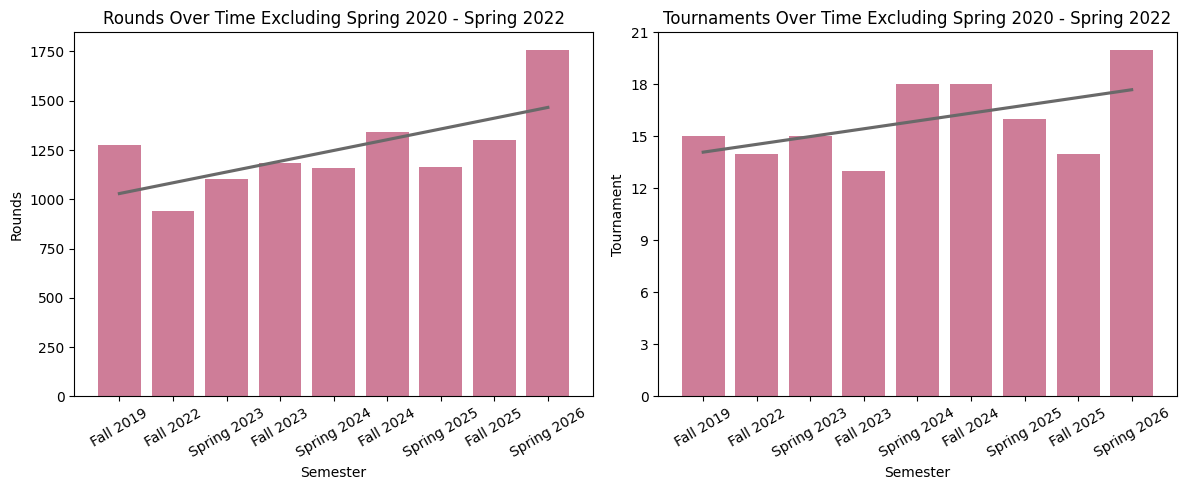

In [6]:
covid_years = ["Spring 2020", "Fall 2020", "Spring 2021", "Fall 2021", "Spring 2022"]
df_exclude_covid_rounds_per_year = df_rounds_per_year[~df_rounds_per_year["Semester"].isin(covid_years)]
df_exclude_covid_tournaments_per_year = df_tournaments_per_year[~df_tournaments_per_year["Semester"].isin(covid_years)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df_exclude_covid_rounds_per_year, x="Semester", y="Rounds", color="palevioletred", ax=axes[0])
axes[0].set_title("Rounds Over Time Excluding Spring 2020 - Spring 2022")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=df_exclude_covid_tournaments_per_year, x="Semester", y="Tournament", color="palevioletred", ax=axes[1])
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].set_title("Tournaments Over Time Excluding Spring 2020 - Spring 2022")
axes[1].tick_params(axis='x', rotation=30)

x_positions_r = np.arange(len(df_exclude_covid_tournaments_per_year))
sns.regplot(x=x_positions_r, y=df_exclude_covid_tournaments_per_year['Tournament'], ax=axes[1], scatter=False, color='dimgray', label='Trend', ci=None)
x_positions_t = np.arange(len(df_exclude_covid_rounds_per_year))
sns.regplot(x=x_positions_t, y=df_exclude_covid_rounds_per_year['Rounds'], ax=axes[0], scatter=False, color='dimgray', label='Trend', ci=None)

plt.tight_layout()
plt.show()

In [7]:
print("Mean Number of Rounds per Year: ", df_rounds_per_year["Rounds"].mean())
print("Mean Number of Tournaments per Year: ", df_tournaments_per_year["Tournament"].mean())

print("Mean Number of Rounds per Years Excluding Spring 2020 - Spring 2022: ", df_exclude_covid_rounds_per_year["Rounds"].mean())
print("Mean Number of Tournaments per Year Excluding Spring 2020 - Spring 2022: ", df_exclude_covid_tournaments_per_year["Tournament"].mean())

Mean Number of Rounds per Year:  992.6428571428571
Mean Number of Tournaments per Year:  13.285714285714286
Mean Number of Rounds per Years Excluding Spring 2020 - Spring 2022:  1247.5555555555557
Mean Number of Tournaments per Year Excluding Spring 2020 - Spring 2022:  15.88888888888889


From this data, we can see that the number of rounds have been steadily increasing since Fall 2019, with Spring 2026 having 1.5x the number of rounds seen in Fall 2019. However, the number of tournaments have been increasing at a slower rate.

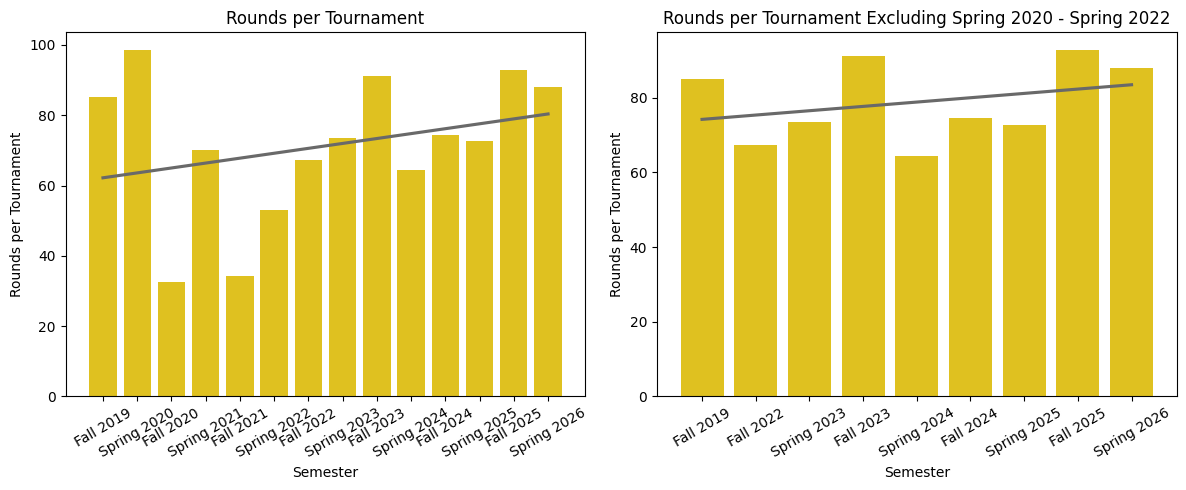

In [8]:
df_rounds_per_tournament = pd.merge(df_rounds_per_year, df_tournaments_per_year, on='Semester', how='inner')
df_rounds_per_tournament = df_rounds_per_tournament.drop(columns=['Year_x', 'Year_y', 'Season_x', 'Season_y'])
df_rounds_per_tournament["Rounds per Tournament"] = df_rounds_per_tournament["Rounds"] / df_rounds_per_tournament["Tournament"]
df_exclude_covid_rounds_per_tournament = df_rounds_per_tournament[~df_rounds_per_tournament["Semester"].isin(covid_years)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df_rounds_per_tournament, x="Semester", y="Rounds per Tournament", color="gold", ax=axes[0])
axes[0].set_title("Rounds per Tournament")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=df_exclude_covid_rounds_per_tournament, x="Semester", y="Rounds per Tournament", color="gold", ax=axes[1])
axes[1].set_title("Rounds per Tournament Excluding Spring 2020 - Spring 2022")
axes[1].tick_params(axis='x', rotation=30)

x_positions = np.arange(len(df_rounds_per_tournament))
sns.regplot(x=x_positions, y=df_rounds_per_tournament['Rounds per Tournament'], ax=axes[0], scatter=False, color='dimgray', label='Trend', ci=None)
x_positions_e = np.arange(len(df_exclude_covid_rounds_per_tournament))
sns.regplot(x=x_positions_e, y=df_exclude_covid_rounds_per_tournament['Rounds per Tournament'], ax=axes[1], scatter=False, color='dimgray', label='Trend', ci=None)

plt.tight_layout()
plt.show()

## Insights and Conclusion

From this section we can learned that APDA debate has been expanding 